In [ ]:
import sys
!{sys.executable} -m pip install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.15-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.15-py3-none-any.whl (160 kB)


In [4]:
import kagglehub
print("kagglehub instalado correctamente")

kagglehub instalado correctamente


100%|██████████| 7.86M/7.86M [00:00<00:00, 10.1MB/s]

Extracting files...


Dataset cargado: C:\Users\Antonio\.cache\kagglehub\datasets\nikhil1e9\loan-default\versions\2\Loan_default.csv
Shape: (255347, 18)

=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 


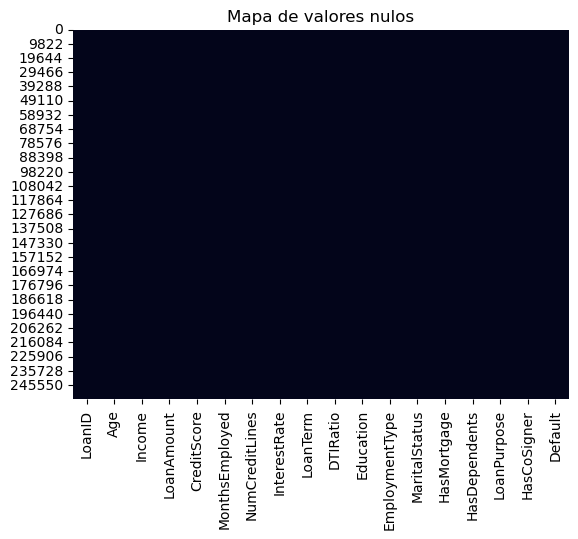


=== ESTADÍSTICOS NUMÉRICOS ===
                   count           mean           std      min       25%  \
Age             255347.0      43.498306     14.990258     18.0     31.00   
Income          255347.0   82499.304597  38963.013729  15000.0  48825.50   
LoanAmount      255347.0  127578.865512  70840.706142   5000.0  66156.00   
CreditScore     255347.0     574.264346    158.903867    300.0    437.00   
MonthsEmployed  255347.0      59.541976     34.643376      0.0     30.00   
NumCreditLines  255347.0       2.501036      1.117018      1.0      2.00   
InterestRate    255347.0      13.492773      6.636443      2.0      7.77   
LoanTerm        255347.0      36.025894     16.969330     12.0     24.00   
DTIRatio        255347.0       0.500212      0.230917      0.1      0.30   
Default         255347.0       0.116128      0.320379      0.0      0.00   

                      50%        75%       max  
Age                 43.00      56.00      69.0  
Income           82466.00  116219

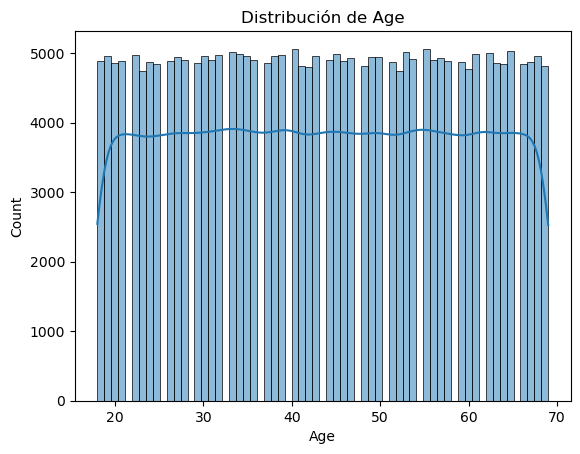

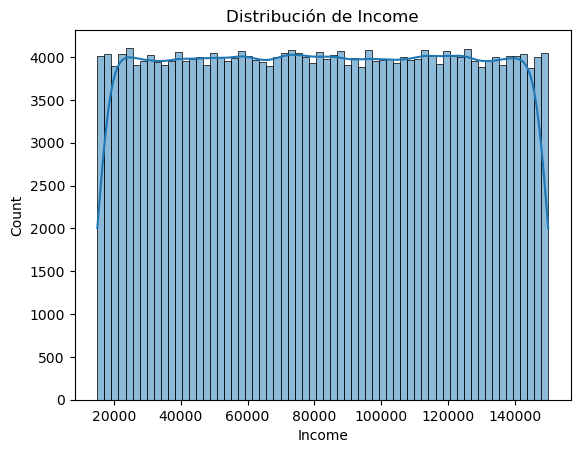

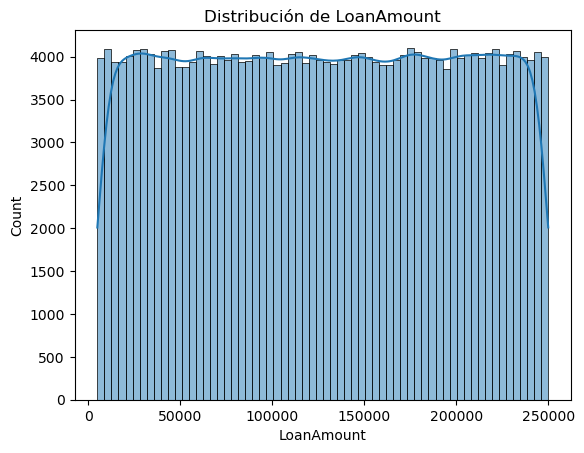

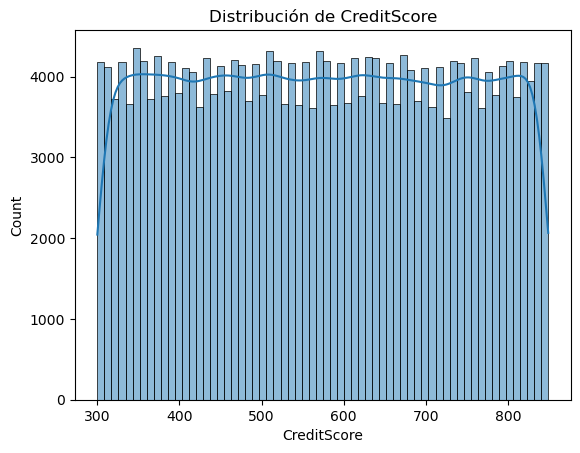

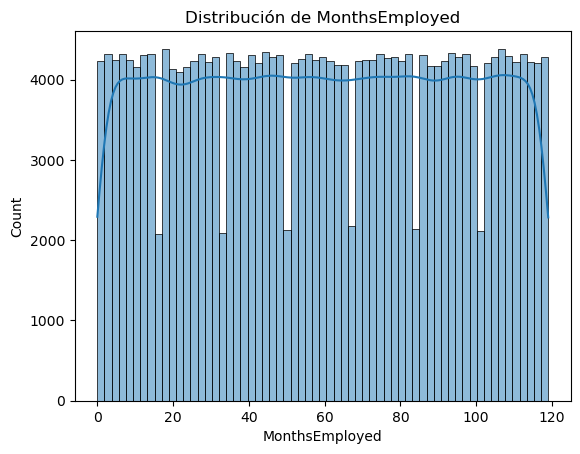

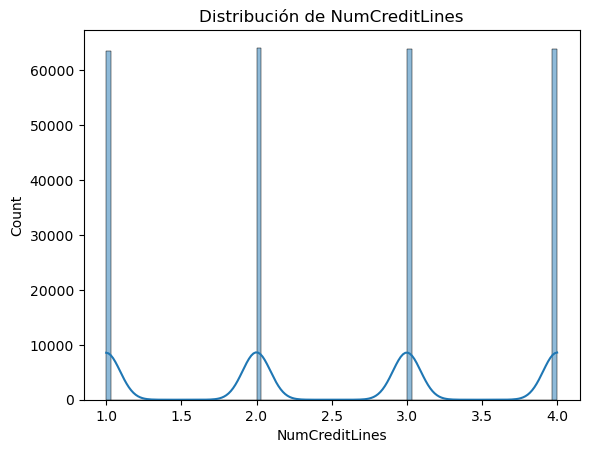

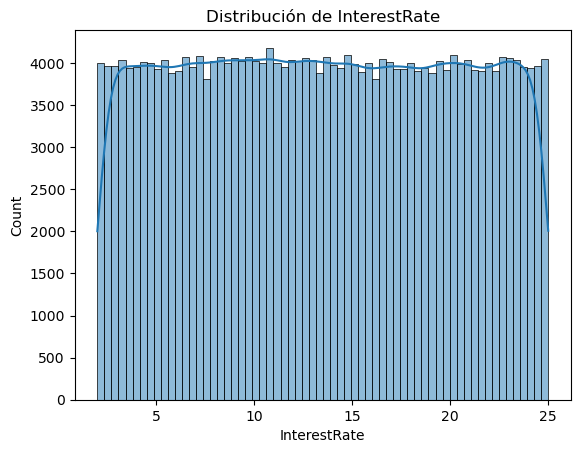

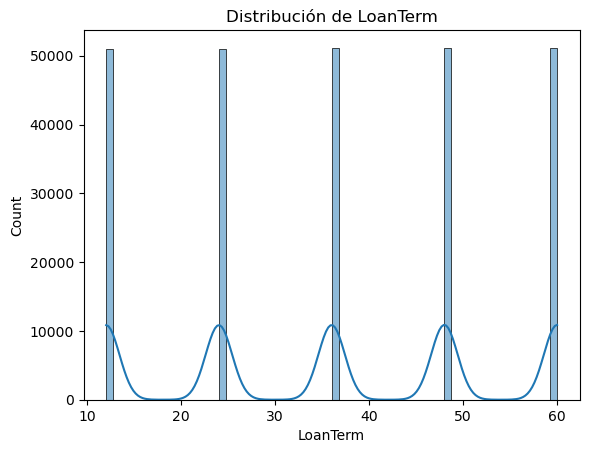

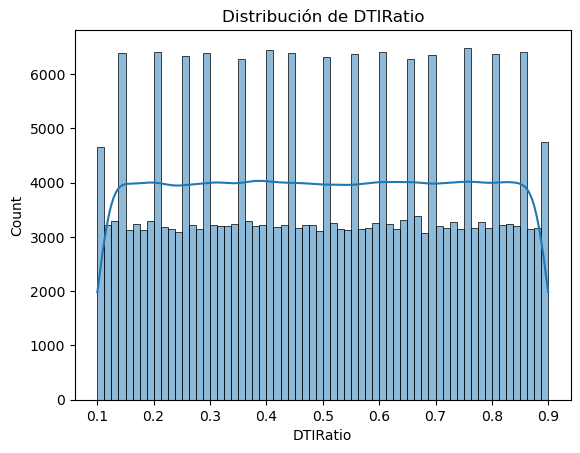

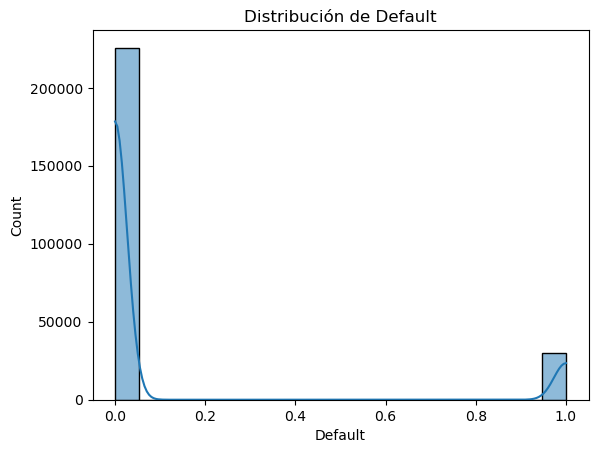

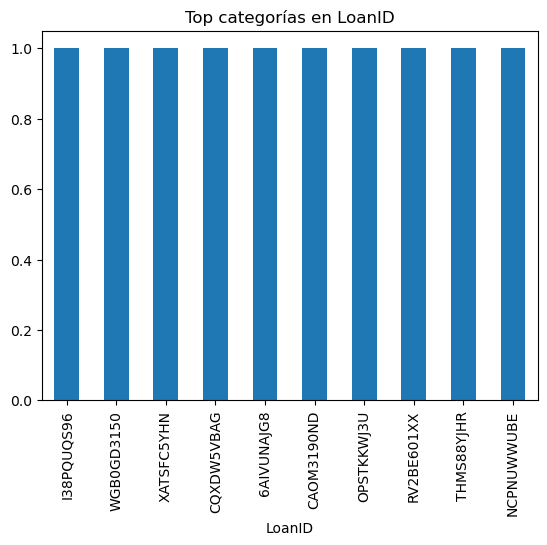

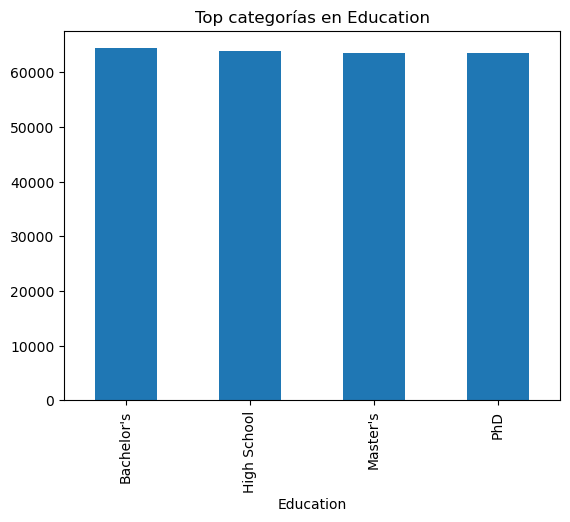

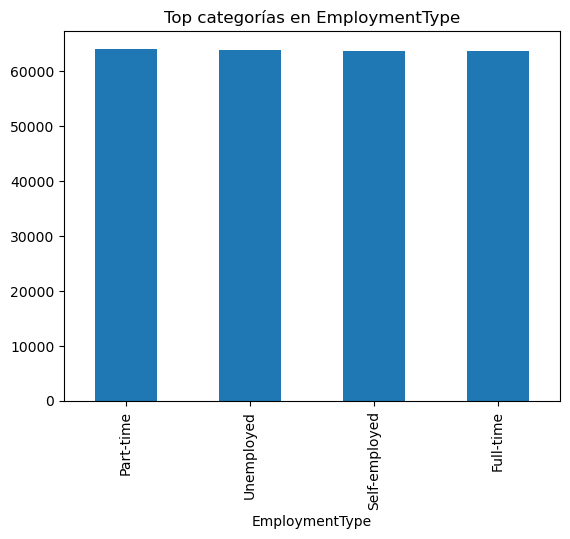

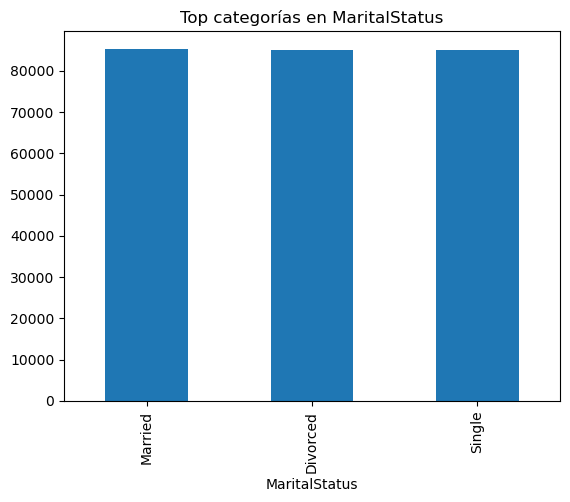

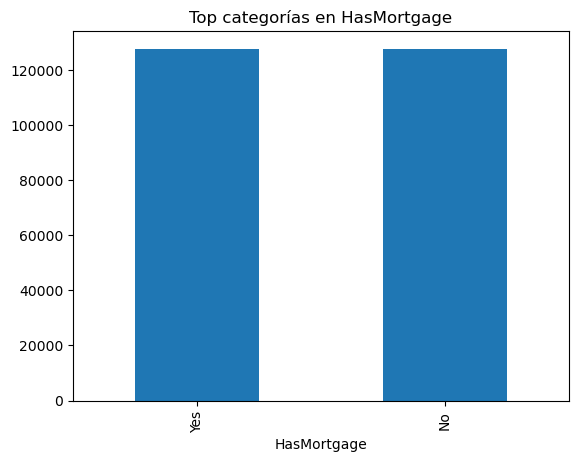

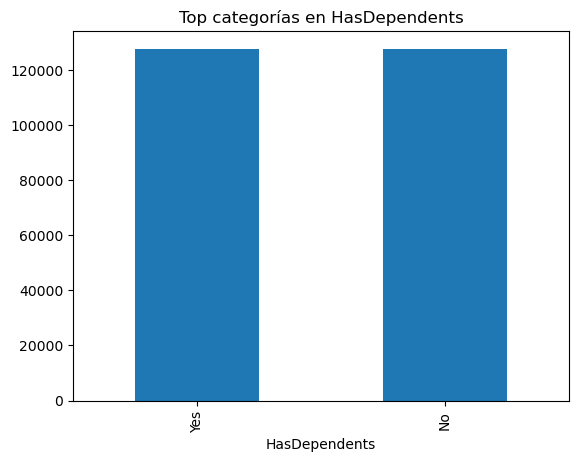

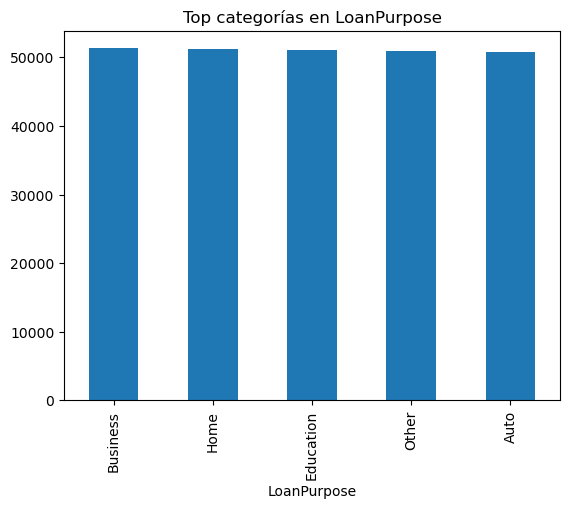

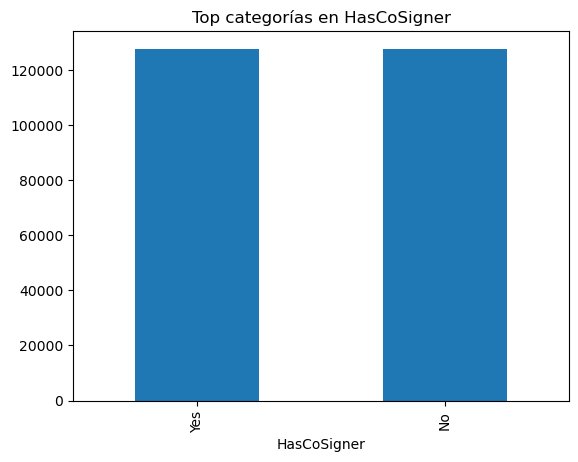

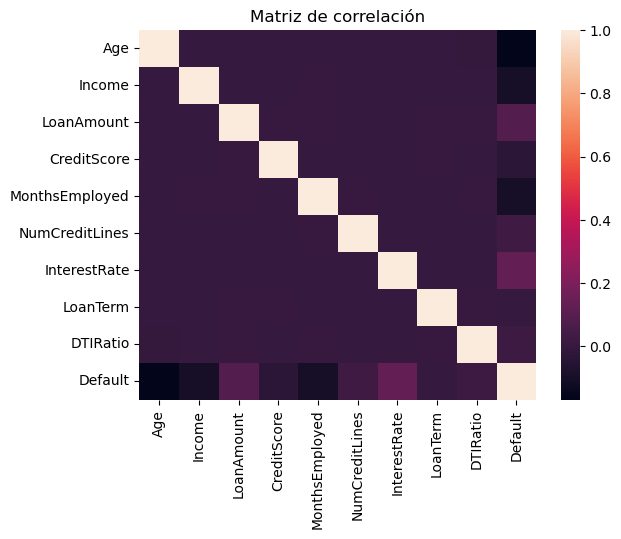

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# =========================
# 1) Descargar y cargar dataset
# =========================
path = kagglehub.dataset_download("nikhil1e9/loan-default")

csv_files = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
if not csv_files:
    raise FileNotFoundError("No se encontró archivo CSV.")

df = pd.read_csv(csv_files[0])

print("Dataset cargado:", csv_files[0])
print("Shape:", df.shape)

# =========================
# 2) Información general
# =========================
print("\n=== INFO GENERAL ===")
print(df.info())

print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

print("\n=== DUPLICADOS ===")
print("Filas duplicadas:", df.duplicated().sum())

# =========================
# 3) Valores nulos
# =========================
print("\n=== PORCENTAJE DE NULOS ===")
null_percent = (df.isna().mean() * 100).sort_values(ascending=False)
print(null_percent[null_percent > 0])

# Visualización de nulos
plt.figure()
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

# =========================
# 4) Variables numéricas
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns

print("\n=== ESTADÍSTICOS NUMÉRICOS ===")
print(df[num_cols].describe().T)

# Histogramas
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

# =========================
# 5) Variables categóricas
# =========================
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categorías en {col}")
    plt.show()

# =========================
# 6) Correlación
# =========================
plt.figure()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False)
plt.title("Matriz de correlación")
plt.show()

# =========================
# 7) Análisis de variable objetivo (si existe)
# =========================
possible_targets = ["default", "loan_status", "target"]

for t in possible_targets:
    if t in df.columns:
        print(f"\n=== DISTRIBUCIÓN DE {t} ===")
        print(df[t].value_counts(normalize=True))
        
        plt.figure()
        sns.countplot(x=df[t])
        plt.title(f"Distribución de {t}")
        plt.show()